# Práctica 01: series de tiempo con Yahoo Finance

**Objetivo:** analizar el precio diario de Bitcoin (`BTC-USD`) y aplicar las fases de Box–Jenkins: identificación, estimación, diagnóstico y pronóstico.

Se sigue la lógica de los tres notebooks y los tres PDF de `TeoriayScrips`. Ejecutar las celdas en orden con el entorno **jupyterev**.

## 1. Librerías

Si se utiliza otro entorno, instalar primero: `%pip install yfinance pandas numpy matplotlib statsmodels`.

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from IPython.display import display
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tools.sm_exceptions import InterpolationWarning

plt.rcParams['figure.figsize'] = (10, 4)
alpha = 0.05

## 2. Llamado al dataset

Fuente: [Bitcoin en Yahoo Finance](https://finance.yahoo.com/quote/BTC-USD/history/). Se utilizan los cierres diarios de 2020 a 2025; `end` es exclusivo.

Los datos se cargan directamente desde Yahoo y se trabajan en memoria dentro del notebook. Esta celda requiere conexión a internet.

In [2]:
simbolo = 'BTC-USD'
inicio = '2020-01-01'
fin = '2026-01-01'

bitcoin = yf.Ticker(simbolo)
data = bitcoin.history(start=inicio, end=fin, interval='1d',
                       auto_adjust=False, actions=False)

data.index = pd.to_datetime(data.index, utc=True).tz_convert(None)
data = data.sort_index()
print('Datos cargados desde Yahoo Finance.')

Datos cargados desde Yahoo Finance.


## 3. Dataset y preparación

`Open`, `High`, `Low` y `Close` son precios en USD; `Volume` es el volumen reportado. La variable del modelo será **Close**.

In [3]:
print('Dimensiones:', data.shape)
print('Periodo:', data.index.min().date(), 'a', data.index.max().date())
display(data.head())
display(data.tail())
data.info()

Dimensiones: (2192, 6)
Periodo: 2020-01-01 a 2025-12-31


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,7200.174316,18565664997
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,6985.470215,20802083465
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,7344.884277,28111481032
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,7410.656738,18444271275
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,7411.317383,19725074095


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,87802.156250,13741199310
2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,87835.835938,15156557929
2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,87138.140625,48411625849
2025-12-30,87134.351562,89297.937500,86735.546875,88430.132812,88430.132812,35586356225
2025-12-31,88429.585938,89080.289062,87130.562500,87508.828125,87508.828125,33830210616


<class 'pandas.DataFrame'>
DatetimeIndex: 2192 entries, 2020-01-01 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2192 non-null   float64
 1   High       2192 non-null   float64
 2   Low        2192 non-null   float64
 3   Close      2192 non-null   float64
 4   Adj Close  2192 non-null   float64
 5   Volume     2192 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 119.9 KB


In [4]:
display(data.describe().T)
display(data.isna().sum().rename('Nulos').to_frame())
print('Fechas duplicadas:', data.index.duplicated().sum())

,count,mean,std,min,25%,50%,75%,max
Open,2192.0,4.716006e+04,3.141991e+04,5.002578e+03,2.208503e+04,3.974162e+04,6.446287e+04,1.247521e+05
High,2192.0,4.808666e+04,3.189897e+04,5.331834e+03,2.260634e+04,4.074582e+04,6.586242e+04,1.261981e+05
Low,2192.0,4.618417e+04,3.090276e+04,4.106981e+03,2.145656e+04,3.872622e+04,6.317450e+04,1.231960e+05
Close,2192.0,4.719485e+04,3.141989e+04,4.970788e+03,2.219608e+04,3.976067e+04,6.451609e+04,1.247525e+05
Adj Close,2192.0,4.719485e+04,3.141989e+04,4.970788e+03,2.219608e+04,3.976067e+04,6.451609e+04,1.247525e+05
Volume,2192.0,3.648228e+10,2.162696e+10,5.331173e+09,2.221117e+10,3.198345e+10,4.537994e+10,3.509679e+11


,Nulos
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Fechas duplicadas: 0


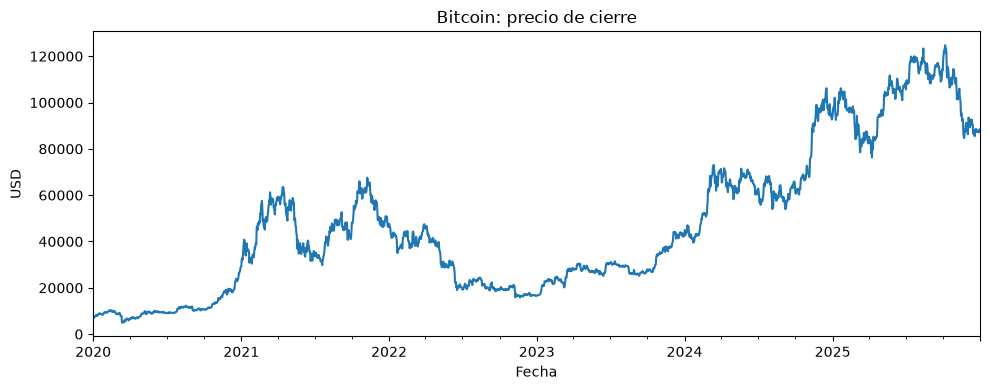

In [5]:
data = data.loc[~data.index.duplicated(keep='first')].copy()
serie = data['Close'].astype(float).asfreq('D')

if serie.isna().any():
    raise ValueError('Hay días sin precio. Revisar la descarga antes de modelar.')
if (serie <= 0).any():
    raise ValueError('Se encontraron precios no positivos.')

serie.plot(title='Bitcoin: precio de cierre', ylabel='USD', xlabel='Fecha')
plt.tight_layout()
plt.show()

## 4. Fase 1: identificación y estacionariedad

### 4.1. División temporal

El primer 80 % se utiliza para identificar y ajustar el modelo. El último 20 % se reserva para evaluar el pronóstico. Las pruebas y la elección de parámetros usan solamente `train`.

,Datos,Desde,Hasta
Entrenamiento,1753,2020-01-01,2024-10-18
Prueba,439,2024-10-19,2025-12-31


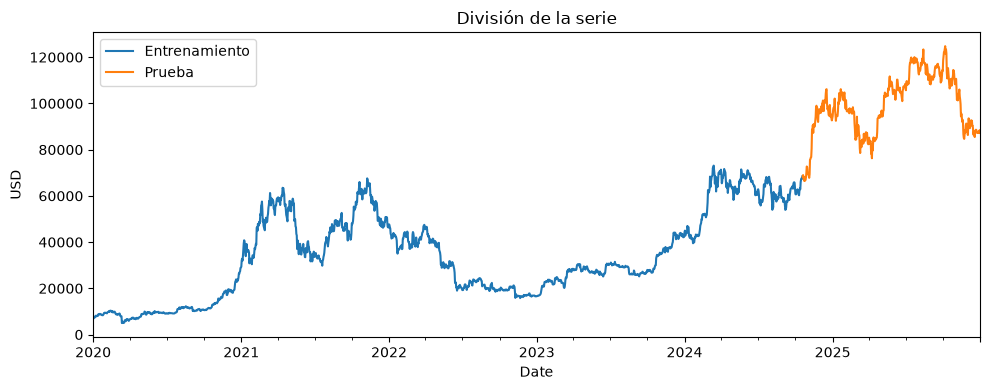

In [6]:
corte = int(len(serie) * 0.8)
train = serie.iloc[:corte]
test = serie.iloc[corte:]

display(pd.DataFrame({
    'Datos': [len(train), len(test)],
    'Desde': [train.index.min().date(), test.index.min().date()],
    'Hasta': [train.index.max().date(), test.index.max().date()]
}, index=['Entrenamiento', 'Prueba']))

train.plot(label='Entrenamiento')
test.plot(label='Prueba')
plt.title('División de la serie')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2. Media móvil y descomposición

Se explora un periodo de siete días porque los datos son diarios. La descomposición describe un patrón semanal supuesto; por sí sola no demuestra estacionalidad.

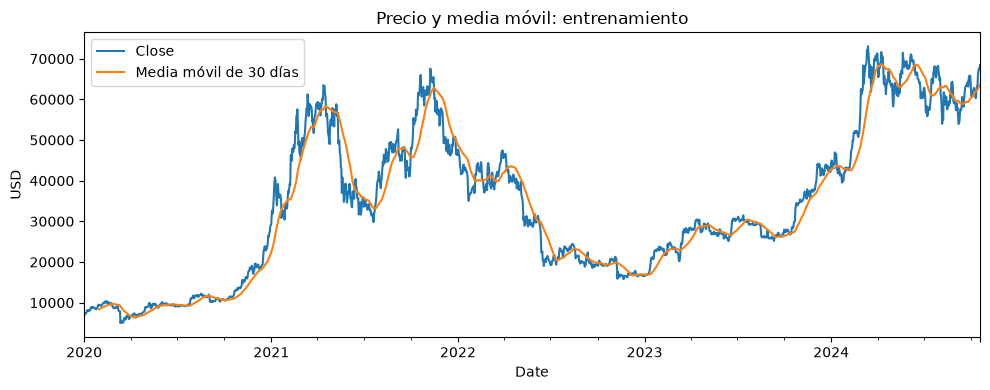

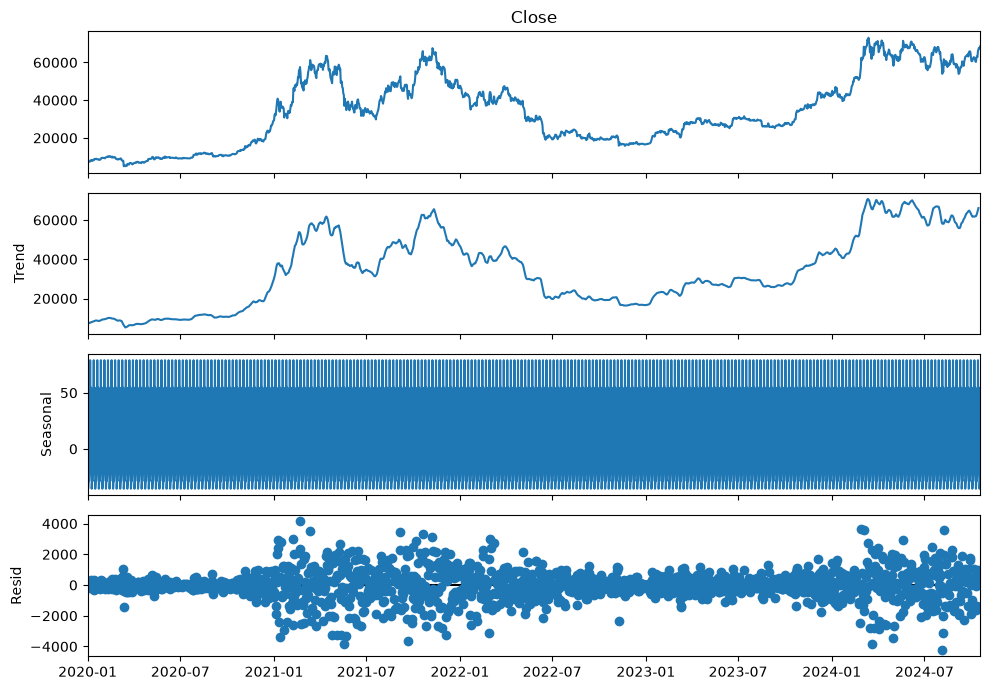

In [7]:
train.plot(label='Close')
train.rolling(30).mean().plot(label='Media móvil de 30 días')
plt.title('Precio y media móvil: entrenamiento')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

descomposicion = seasonal_decompose(train, model='additive', period=7)
fig = descomposicion.plot()
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

### 4.3. FAC y FACP de la serie original

La FAC mide la relación con los rezagos. La FACP mide esa relación descontando los rezagos intermedios. Una FAC que disminuye lentamente puede indicar no estacionariedad.

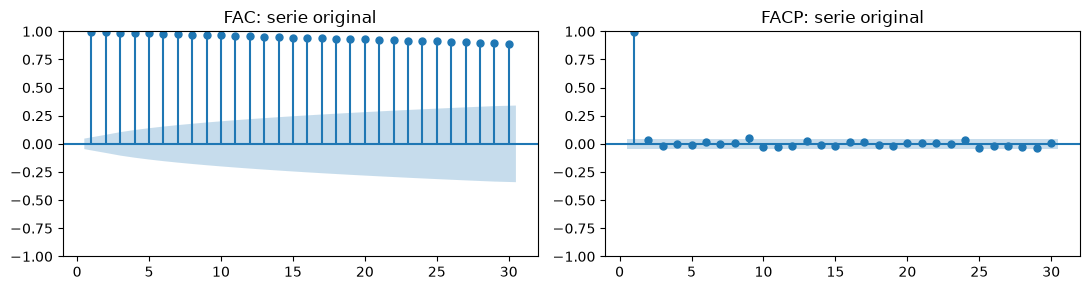

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(train, lags=30, zero=False, ax=axes[0], title='FAC: serie original')
plot_pacf(train, lags=30, zero=False, method='ywm', ax=axes[1],
          title='FACP: serie original')
plt.tight_layout()
plt.show()

### 4.4. Pruebas de estacionariedad

Se usa una significancia de 0,05:

| Prueba | Hipótesis nula | Evidencia compatible con estacionariedad |
|---|---|---|
| ADF (Dickey–Fuller aumentado) | Existe raíz unitaria | p < 0,05 |
| KPSS | La serie es estacionaria alrededor de una constante | p ≥ 0,05 |

Se busca coincidencia entre ambas pruebas. Si discrepan, el resultado no es concluyente. No rechazar una hipótesis no demuestra que sea verdadera. Los p-valores KPSS de 0,01 y 0,10 son límites de su tabla.

In [9]:
def probar_estacionariedad(x, nombre, orden):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        warnings.simplefilter('ignore', FutureWarning)
        adf = adfuller(x.dropna(), regression='c', autolag='AIC')
        resultado_kpss = kpss(x.dropna(), regression='c', nlags='auto')
    compatible = adf[1] < alpha and resultado_kpss[1] >= alpha
    return {'Serie': nombre, 'd': orden, 'ADF': adf[0], 'p_ADF': adf[1],
            'KPSS': resultado_kpss[0], 'p_KPSS': resultado_kpss[1],
            'Compatible': compatible}

prueba_original = probar_estacionariedad(train, 'Original', 0)
display(pd.DataFrame([prueba_original]))

,Serie,d,ADF,p_ADF,KPSS,p_KPSS,Compatible
0,Original,0,-1.122012,0.706215,2.058824,0.01,False


### 4.5. Primera y segunda diferencia

Primera diferencia: `y(t) − y(t−1)`. Segunda diferencia: diferenciar otra vez la primera diferencia (`diff().diff()`, no `diff(2)`). Se muestran ambas para comparar, pero se elige el **menor d** compatible con las pruebas, evitando diferencias innecesarias.

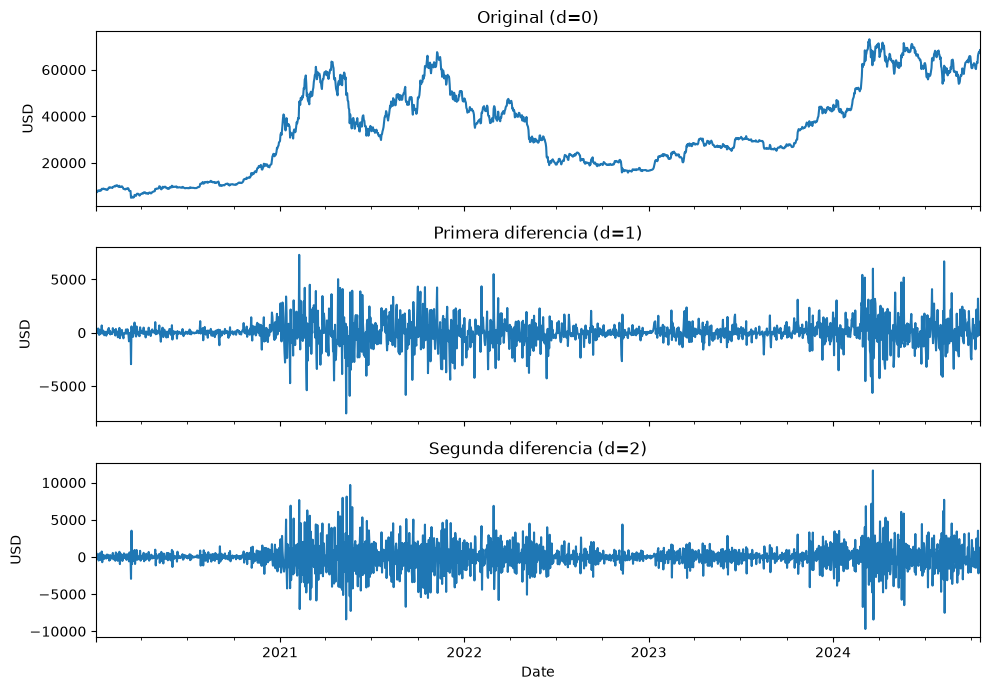

In [10]:
train_diff = train.diff().dropna()
train_diff2 = train_diff.diff().dropna()
series = [train, train_diff, train_diff2]
nombres = ['Original (d=0)', 'Primera diferencia (d=1)', 'Segunda diferencia (d=2)']

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for x, nombre, ax in zip(series, nombres, axes):
    x.plot(ax=ax, title=nombre)
    ax.set_ylabel('USD')
plt.tight_layout()
plt.show()

In [11]:
pruebas = pd.DataFrame([
    prueba_original,
    probar_estacionariedad(train_diff, 'Primera diferencia', 1),
    probar_estacionariedad(train_diff2, 'Segunda diferencia', 2)
])
display(pruebas)

opciones_d = pruebas.loc[pruebas['Compatible'], 'd']
if opciones_d.empty:
    raise ValueError('No hay coincidencia con d ≤ 2. Revisar transformaciones o cambios estructurales.')

d = int(opciones_d.min())
serie_estacionaria = series[d]
print(f'Se elige d = {d}: {nombres[d]}.')
print('Resultado compatible con estacionariedad en media; falta revisar la varianza.')

,Serie,d,ADF,p_ADF,KPSS,p_KPSS,Compatible
0,Original,0,-1.122012,7.062146e-01,2.058824,0.01,False
1,Primera diferencia,1,-43.995523,0.000000e+00,0.109962,0.10,True
2,Segunda diferencia,2,-15.588308,1.894190e-28,0.096632,0.10,True


Se elige d = 1: Primera diferencia (d=1).
Resultado compatible con estacionariedad en media; falta revisar la varianza.


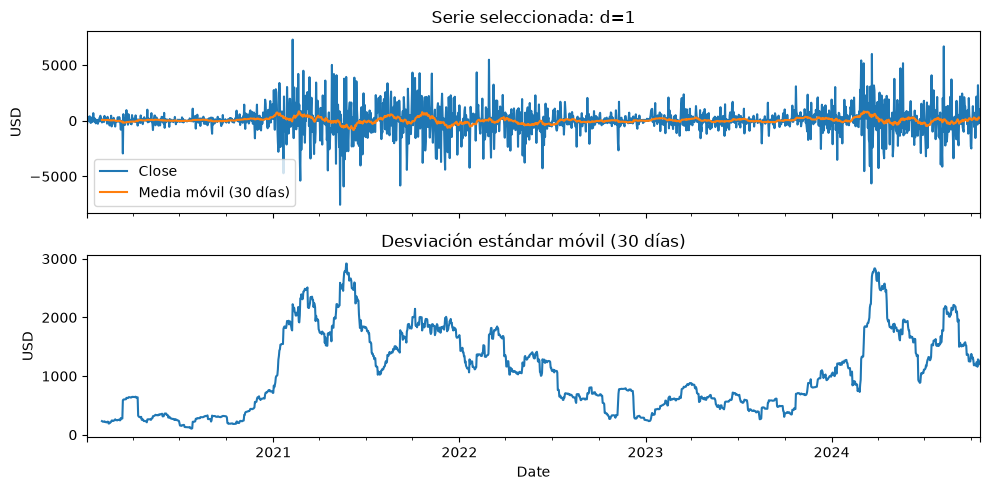

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
serie_estacionaria.plot(ax=axes[0], title=f'Serie seleccionada: d={d}')
serie_estacionaria.rolling(30).mean().plot(ax=axes[0], label='Media móvil (30 días)')
axes[0].set_ylabel('USD')
axes[0].legend()
serie_estacionaria.rolling(30).std().plot(ax=axes[1], title='Desviación estándar móvil (30 días)')
axes[1].set_ylabel('USD')
plt.tight_layout()
plt.show()

### 4.6. FAC y FACP para identificar p y q

| Modelo sobre la serie estacionaria | FAC | FACP |
|---|---|---|
| AR(p) | Decae gradualmente | Corte después de p |
| MA(q) | Corte después de q | Decae gradualmente |
| ARMA(p,q) | Decae gradualmente | Decae gradualmente |

Estos patrones son orientativos. Se comparan órdenes pequeños con AIC y BIC para apoyar la elección.

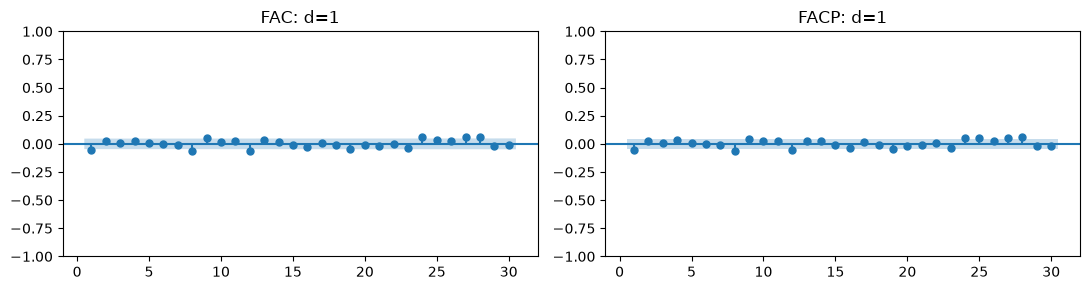

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(serie_estacionaria, lags=30, zero=False, ax=axes[0], title=f'FAC: d={d}')
plot_pacf(serie_estacionaria, lags=30, zero=False, method='ywm', ax=axes[1],
          title=f'FACP: d={d}')
plt.tight_layout()
plt.show()

## 5. Fase 2: estimación y comparación de modelos

Con `d=0`, ARIMA(p,0,0) es AR, ARIMA(0,0,q) es MA y ARIMA(p,0,q) es ARMA. Con `d>0`, el modelo de la serie original es **ARIMA(p,d,q)**, aunque las diferencias se modelen con AR, MA o ARMA.

Se prueban `p` y `q` entre 0 y 3. Se incluye ARIMA(0,1,0), un paseo aleatorio sin deriva, cuando `d=1`. Se ajusta **train original**: ARIMA realiza las diferencias internamente y devuelve pronósticos en USD. Se usa constante si `d=0` y sin tendencia determinista si `d>0`.

In [14]:
def nombre_modelo(p, d, q):
    if d > 0:
        return f'ARIMA({p},{d},{q})'
    if p > 0 and q == 0:
        return f'AR({p})'
    if p == 0 and q > 0:
        return f'MA({q})'
    if p > 0 and q > 0:
        return f'ARMA({p},{q})'
    return 'Media constante'

modelos = {}
resultados = []
descartados = []
tendencia = 'c' if d == 0 else 'n'

for p in range(4):
    for q in range(4):
        orden = (p, d, q)
        try:
            with warnings.catch_warnings(record=True) as avisos:
                ajuste = ARIMA(train, order=orden, trend=tendencia).fit(
                    method_kwargs={'maxiter': 200})
            if not ajuste.mle_retvals.get('converged', False):
                descartados.append((orden, 'No convergió'))
                continue
            if not np.isfinite([ajuste.aic, ajuste.bic]).all():
                descartados.append((orden, 'AIC o BIC no finito'))
                continue
            modelos[orden] = ajuste
            resultados.append({'Modelo': nombre_modelo(*orden), 'Orden': orden,
                               'AIC': ajuste.aic, 'BIC': ajuste.bic,
                               'Avisos': len(avisos)})
        except (ValueError, np.linalg.LinAlgError) as error:
            descartados.append((orden, str(error)))

if not resultados:
    raise ValueError('Ningún modelo pudo estimarse correctamente.')

comparacion = pd.DataFrame(resultados).sort_values('AIC').reset_index(drop=True)
display(comparacion)
if descartados:
    display(pd.DataFrame(descartados, columns=['Orden descartado', 'Motivo']))

,Modelo,Orden,AIC,BIC,Avisos
0,"ARIMA(3,1,3)","(3, 1, 3)",29976.733843,30015.013436,0
1,"ARIMA(1,1,0)","(1, 1, 0)",29977.114127,29988.051154,0
2,"ARIMA(0,1,1)","(0, 1, 1)",29977.350441,29988.287468,0
3,"ARIMA(0,1,2)","(0, 1, 2)",29977.909848,29994.315388,0
4,"ARIMA(2,1,0)","(2, 1, 0)",29977.921758,29994.327298,0
5,"ARIMA(1,1,1)","(1, 1, 1)",29978.166772,29994.572312,0
6,"ARIMA(1,1,2)","(1, 1, 2)",29978.862593,30000.736646,0
7,"ARIMA(2,1,1)","(2, 1, 1)",29978.913813,30000.787866,0
8,"ARIMA(2,1,2)","(2, 1, 2)",29979.480076,30006.822642,0
9,"ARIMA(0,1,0)","(0, 1, 0)",29979.527490,29984.996003,0


## 6. Fase 3: diagnóstico de residuos

### 6.1. Selección con AIC y Ljung–Box

Un AIC menor indica un mejor equilibrio entre ajuste y complejidad dentro de esta comparación. Siguiendo Box–Jenkins, se revisan los modelos en ese orden y se elige el primero sin autocorrelación residual detectada a 10 y 20 rezagos.

Ljung–Box: H₀ = no hay autocorrelación hasta el rezago evaluado. Se descartan los residuos iniciales de inicialización y se descuentan `p+q` grados de libertad. Pasar esta prueba no garantiza independencia ni varianza constante.

In [15]:
diagnosticos = []
for orden in comparacion['Orden']:
    ajuste = modelos[orden]
    resid = ajuste.resid.iloc[max(d, ajuste.loglikelihood_burn):].dropna()
    lb = acorr_ljungbox(resid, lags=[10, 20], model_df=orden[0] + orden[2],
                       return_df=True)
    diagnosticos.append({'Orden': orden, 'p_LB10': lb['lb_pvalue'].iloc[0],
                         'p_LB20': lb['lb_pvalue'].iloc[1],
                         'Sin autocorrelación detectada': bool((lb['lb_pvalue'] >= alpha).all())})

comparacion = comparacion.merge(pd.DataFrame(diagnosticos), on='Orden').sort_values('AIC')
display(comparacion)
aptos = comparacion[comparacion['Sin autocorrelación detectada']]

if aptos.empty:
    orden_elegido = comparacion.iloc[0]['Orden']
    print('Ningún candidato pasa Ljung–Box. Se conserva el menor AIC como modelo provisional.')
else:
    orden_elegido = aptos.iloc[0]['Orden']

modelo = modelos[orden_elegido]
nombre = nombre_modelo(*orden_elegido)
residuales = modelo.resid.iloc[max(d, modelo.loglikelihood_burn):].dropna()
print('Modelo elegido:', nombre)
print(modelo.summary())

,Modelo,Orden,AIC,BIC,Avisos,p_LB10,p_LB20,Sin autocorrelación detectada
0,"ARIMA(3,1,3)","(3, 1, 3)",29976.733843,30015.013436,0,0.088342,0.016167,False
1,"ARIMA(1,1,0)","(1, 1, 0)",29977.114127,29988.051154,0,0.134606,0.063671,True
2,"ARIMA(0,1,1)","(0, 1, 1)",29977.350441,29988.287468,0,0.126376,0.060309,True
3,"ARIMA(0,1,2)","(0, 1, 2)",29977.909848,29994.315388,0,0.117102,0.052970,True
4,"ARIMA(2,1,0)","(2, 1, 0)",29977.921758,29994.327298,0,0.117904,0.053350,True
5,"ARIMA(1,1,1)","(1, 1, 1)",29978.166772,29994.572312,0,0.119827,0.057055,True
6,"ARIMA(1,1,2)","(1, 1, 2)",29978.862593,30000.736646,0,0.095519,0.047703,False
7,"ARIMA(2,1,1)","(2, 1, 1)",29978.913813,30000.787866,0,0.094152,0.046084,False
8,"ARIMA(2,1,2)","(2, 1, 2)",29979.480076,30006.822642,0,0.129055,0.071070,True
9,"ARIMA(0,1,0)","(0, 1, 0)",29979.527490,29984.996003,0,0.046390,0.022160,False


Modelo elegido: ARIMA(1,1,0)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1753
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -14986.557
Date:                Sun, 13 Sep 2026   AIC                          29977.114
Time:                        20:10:25   BIC                          29988.051
Sample:                    01-01-2020   HQIC                         29981.157
                         - 10-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0500      0.017     -2.858      0.004      -0.084      -0.016
sigma2      1.576e+06    2.8e+04     56.357      0.000    1.52e+06    1.63e+06
Ljung-Box (L1) (Q):    

### 6.2. Gráficos de los residuos

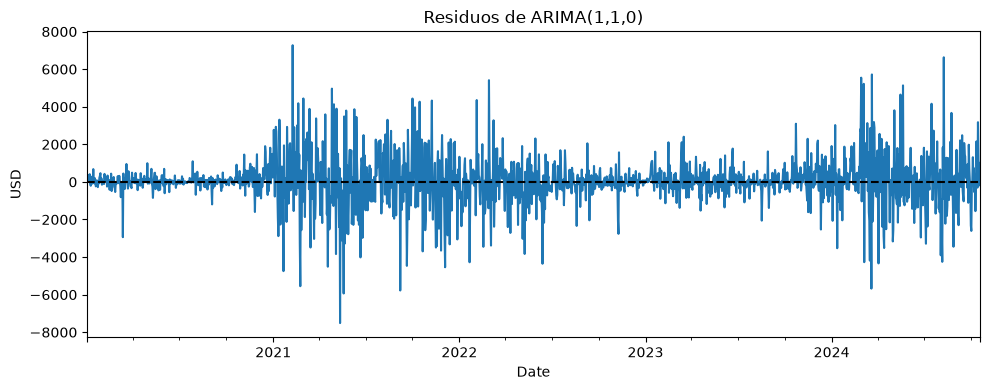

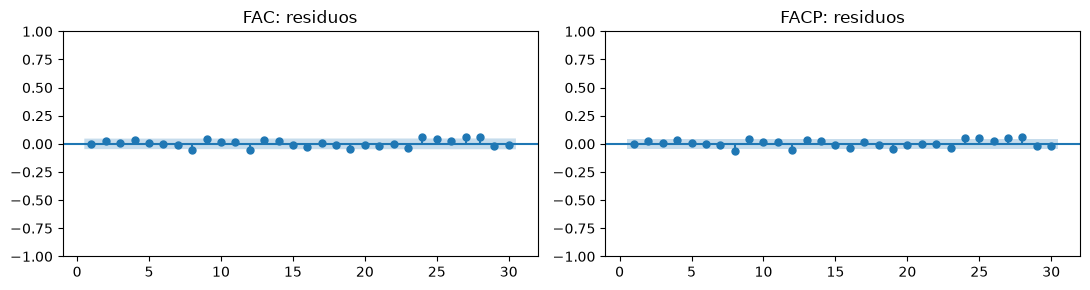

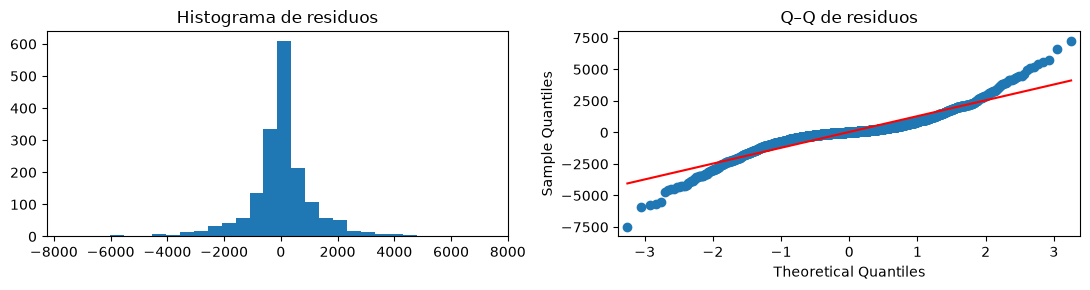

In [16]:
residuales.plot(title=f'Residuos de {nombre}', ylabel='USD')
plt.axhline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(residuales, lags=30, zero=False, ax=axes[0], title='FAC: residuos')
plot_pacf(residuales, lags=30, zero=False, method='ywm', ax=axes[1], title='FACP: residuos')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(residuales, bins=30)
axes[0].set_title('Histograma de residuos')
qqplot(residuales, line='s', ax=axes[1])
axes[1].set_title('Q–Q de residuos')
plt.tight_layout()
plt.show()

### 6.3. Ljung–Box, ARCH y Jarque–Bera

ARCH contrasta ausencia de heterocedasticidad condicional; Jarque–Bera contrasta normalidad. Si p < 0,05 se rechaza su hipótesis nula. Una media próxima a cero se revisa descriptivamente.

In [17]:
lb = acorr_ljungbox(residuales, lags=[10, 20],
                   model_df=orden_elegido[0] + orden_elegido[2], return_df=True)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)
    arch = het_arch(residuales, nlags=10, ddof=orden_elegido[0] + orden_elegido[2])
jb = jarque_bera(residuales)

print(f'Media de los residuos: {residuales.mean():.2f} USD')
display(lb)
display(pd.DataFrame({'Prueba': ['ARCH', 'Jarque–Bera'],
                      'Estadístico': [arch[0], jb[0]], 'p_valor': [arch[1], jb[1]]}))
print('Ljung–Box:', 'hay autocorrelación residual.' if (lb['lb_pvalue'] < alpha).any()
      else 'no se detecta autocorrelación en los rezagos evaluados.')
print('ARCH:', 'se detecta varianza condicional cambiante.' if arch[1] < alpha
      else 'no se detectan efectos ARCH.')
print('Jarque–Bera:', 'se rechaza normalidad.' if jb[1] < alpha
      else 'no se rechaza normalidad.')

Media de los residuos: 36.79 USD


,lb_stat,lb_pvalue
10,13.668757,0.134606
20,29.149433,0.063671


,Prueba,Estadístico,p_valor
0,ARCH,153.222276,8.093389e-28
1,Jarque–Bera,2030.606776,0.000000e+00


Ljung–Box: no se detecta autocorrelación en los rezagos evaluados.
ARCH: se detecta varianza condicional cambiante.
Jarque–Bera: se rechaza normalidad.


## 7. Fase 4: pronóstico y evaluación

### 7.1. Pronóstico del conjunto de prueba

El modelo queda fijado antes de consultar los errores de prueba. Se pronostica todo el bloque desde el último día de entrenamiento, sin actualizar con valores de `test`. Se compara con una referencia ingenua: repetir el último cierre conocido.

Los intervalos del 95 % dependen de los supuestos del modelo; su cobertura puede ser inadecuada si ARCH o Jarque–Bera rechazan sus hipótesis.

,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2024-10-19,68362.734375,68367.857815,68418.789062,65907.053344,70828.662286
2024-10-20,69001.703125,68370.403557,68418.789062,64976.160549,71764.646566
2024-10-21,67367.851562,68370.276311,68418.789062,64245.352527,72495.200095
2024-10-22,67361.406250,68370.282671,68418.789062,63626.058148,73114.507195
2024-10-23,66432.195312,68370.282354,68418.789062,63078.741138,73661.823569


,Real,Pronóstico,Ingenuo,Inferior 95%,Superior 95%
2025-12-27,87802.156250,68370.282369,68418.789062,19483.903487,117256.661250
2025-12-28,87835.835938,68370.282369,68418.789062,19427.757108,117312.807629
2025-12-29,87138.140625,68370.282369,68418.789062,19371.675067,117368.889671
2025-12-30,88430.132812,68370.282369,68418.789062,19315.657141,117424.907596
2025-12-31,87508.828125,68370.282369,68418.789062,19259.703112,117480.861625


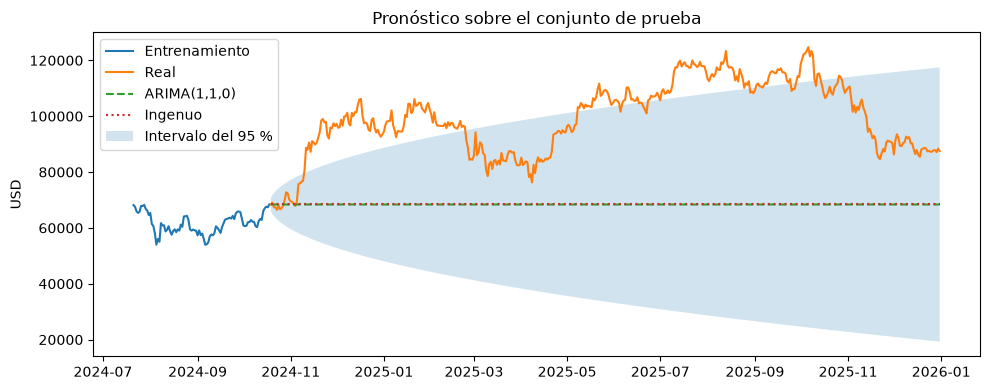

In [18]:
pronostico = modelo.get_forecast(steps=len(test))
intervalo = pronostico.conf_int(alpha=alpha)
prediccion = pronostico.predicted_mean

evaluacion = pd.DataFrame({'Real': test, 'Pronóstico': prediccion,
                           'Ingenuo': train.iloc[-1],
                           'Inferior 95%': intervalo.iloc[:, 0],
                           'Superior 95%': intervalo.iloc[:, 1]})
display(evaluacion.head())
display(evaluacion.tail())

plt.plot(train.tail(90), label='Entrenamiento')
plt.plot(test, label='Real')
plt.plot(prediccion, label=nombre, linestyle='--')
plt.plot(test.index, evaluacion['Ingenuo'], label='Ingenuo', linestyle=':')
plt.fill_between(test.index, intervalo.iloc[:, 0], intervalo.iloc[:, 1],
                 alpha=0.2, label='Intervalo del 95 %')
plt.title('Pronóstico sobre el conjunto de prueba')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

### 7.2. Errores del pronóstico

MSE, RMSE, MAE y MAPE: cuanto menores, mejor. RMSE y MAE se expresan en USD, MSE en USD² y MAPE en porcentaje. Las métricas del bloque completo se complementan con sus primeros 30 días, un horizonte más corto.

In [19]:
def metricas(real, estimado):
    error = real - estimado
    mse = np.mean(error ** 2)
    return {'MSE': mse, 'RMSE': np.sqrt(mse), 'MAE': np.mean(np.abs(error)),
            'MAPE (%)': np.mean(np.abs(error / real)) * 100}

metricas_test = pd.DataFrame({
    nombre: metricas(test, evaluacion['Pronóstico']),
    'Ingenuo': metricas(test, evaluacion['Ingenuo'])
}).T
print('Todo el conjunto de prueba:')
display(metricas_test.round(2))
print('Primeros 30 días de prueba:')
display(pd.DataFrame({
    nombre: metricas(test.iloc[:30], evaluacion['Pronóstico'].iloc[:30]),
    'Ingenuo': metricas(test.iloc[:30], evaluacion['Ingenuo'].iloc[:30])
}).T.round(2))

Todo el conjunto de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(1,1,0)",1.128829e+09,33598.05,31063.88,30.00
Ingenuo,1.125821e+09,33553.26,31017.37,29.95


Primeros 30 días de prueba:


,MSE,RMSE,MAE,MAPE (%)
"ARIMA(1,1,0)",1.188108e+08,10900.03,7161.09,8.51
Ingenuo,1.181717e+08,10870.68,7141.77,8.49


### 7.3. Reajuste y pronóstico de 30 días posteriores al dataset

Se conserva el orden elegido y se reestiman los parámetros con toda la serie. El horizonte empieza después de la última fecha descargada; este pronóstico no es una evaluación con datos observados.

,Pronóstico,Inferior 95%,Superior 95%
2026-01-01,87549.95,84633.93,90465.97
2026-01-02,87548.11,83515.21,91581.01
2026-01-03,87548.19,82643.32,92453.07
2026-01-04,87548.19,81904.62,93191.75
2026-01-05,87548.19,81252.00,93844.37
2026-01-06,87548.19,80660.95,94435.43
2026-01-07,87548.19,80116.76,94979.62
2026-01-08,87548.19,79609.78,95486.60
2026-01-09,87548.19,79133.30,95963.08
2026-01-10,87548.19,78682.38,96414.00


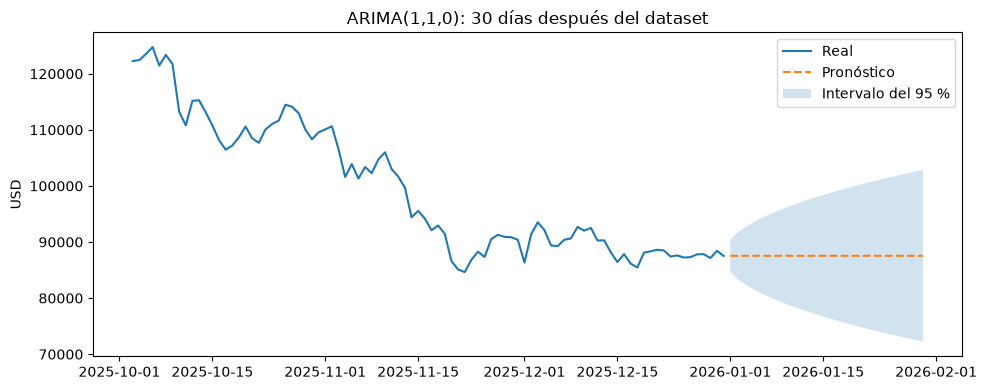

In [20]:
modelo_final = ARIMA(serie, order=orden_elegido, trend=tendencia).fit(
    method_kwargs={'maxiter': 200})
if not modelo_final.mle_retvals.get('converged', False):
    raise ValueError('El reajuste final no convergió. Revisar antes de pronosticar.')

futuro = modelo_final.get_forecast(steps=30)
intervalo_futuro = futuro.conf_int(alpha=alpha)
tabla_futuro = pd.DataFrame({'Pronóstico': futuro.predicted_mean,
                             'Inferior 95%': intervalo_futuro.iloc[:, 0],
                             'Superior 95%': intervalo_futuro.iloc[:, 1]})
display(tabla_futuro.round(2))

plt.plot(serie.tail(90), label='Real')
plt.plot(tabla_futuro['Pronóstico'], label='Pronóstico', linestyle='--')
plt.fill_between(tabla_futuro.index, tabla_futuro['Inferior 95%'],
                 tabla_futuro['Superior 95%'], alpha=0.2, label='Intervalo del 95 %')
plt.title(f'{nombre}: 30 días después del dataset')
plt.ylabel('USD')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Conclusiones

In [21]:
print(f'1. Se analizaron {len(serie)} precios diarios de {simbolo}.')
print(f'2. Se seleccionó d={d}, el menor orden compatible con ADF y KPSS.')
print(f'3. El modelo elegido entre los candidatos fue {nombre}.')
rmse_modelo = metricas_test.loc[nombre, 'RMSE']
rmse_ingenuo = metricas_test.loc['Ingenuo', 'RMSE']
print(f'4. RMSE de prueba: {rmse_modelo:.2f} USD; referencia ingenua: {rmse_ingenuo:.2f} USD.')
if np.isclose(rmse_modelo, rmse_ingenuo):
    print('   El resultado es equivalente al pronóstico ingenuo.')
elif rmse_modelo < rmse_ingenuo:
    print('   El modelo mejora la referencia en este periodo.')
else:
    print('   El modelo no mejora la referencia en este periodo.')
if (lb['lb_pvalue'] < alpha).any():
    print('5. Queda autocorrelación residual: revisar la identificación del modelo.')
else:
    print('5. No se detecta autocorrelación residual en los rezagos evaluados.')
if arch[1] < alpha or jb[1] < alpha:
    print('6. Hay limitaciones de varianza o normalidad: los intervalos son aproximados.')
    print('   Diferenciar no garantiza varianza constante; explorar logaritmos o ARCH/GARCH como extensión.')
else:
    print('6. Las pruebas no detectaron efectos ARCH ni desviaciones de normalidad al 5 %.')

1. Se analizaron 2192 precios diarios de BTC-USD.
2. Se seleccionó d=1, el menor orden compatible con ADF y KPSS.
3. El modelo elegido entre los candidatos fue ARIMA(1,1,0).
4. RMSE de prueba: 33598.05 USD; referencia ingenua: 33553.26 USD.
   El modelo no mejora la referencia en este periodo.
5. No se detecta autocorrelación residual en los rezagos evaluados.
6. Hay limitaciones de varianza o normalidad: los intervalos son aproximados.
   Diferenciar no garantiza varianza constante; explorar logaritmos o ARCH/GARCH como extensión.


### Referencias

Material de clase: `01. Introducción a la programación para Series de Tiempo.ipynb`, `02. Series estacionarias y no estacionarias.ipynb`, `04. Modelos ARMA.ipynb` y los tres PDF de `TeoriayScrips`.

Consulta técnica: [yfinance](https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html), [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html), [KPSS](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.kpss.html) y [Ljung–Box](https://www.statsmodels.org/stable/generated/statsmodels.stats.diagnostic.acorr_ljungbox.html).